In [104]:
# Libraries
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error

In [66]:
from utils import *

In [67]:
# importing dataset
df = pd.read_csv('../data/workable_data.csv')

In [95]:
# Select target and features
X = df.drop('failure', axis=1)
y = df['failure']

In [87]:
# Split the data in a way that the test data contains 1 of the failures and the train 3 of the failures
split_index = int(len(df) * 0.7)
X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

In [70]:
# SMOTE with sampling_strategy = 0.05 
smote = SMOTE(sampling_strategy=0.05, random_state=42) 
X_train, y_train = smote.fit_resample(X_train, y_train)

In [71]:
# Fit the model
rf = RandomForestClassifier(
    max_depth=10,         
    min_samples_leaf=10,   
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


# Feature importance

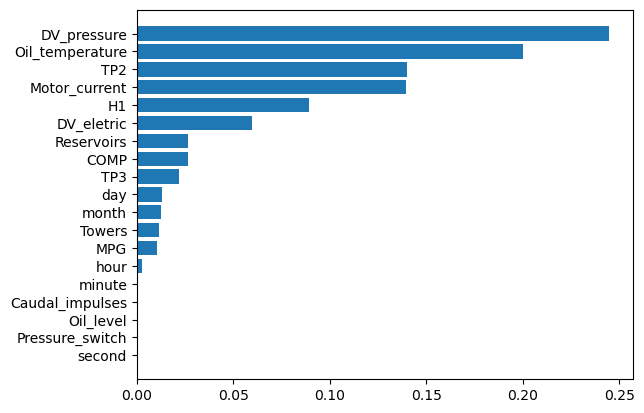

In [72]:
sort_idx = rf.feature_importances_.argsort()
plt.barh(X.columns[sort_idx], rf.feature_importances_[sort_idx])
plt.show();

## First Drop

In [ ]:
X = X.drop(['second', 'Pressure_switch', 'Oil_level', 'Caudal_impulses', 'minute', 'hour', 'MPG', 'COMP'], axis=1)

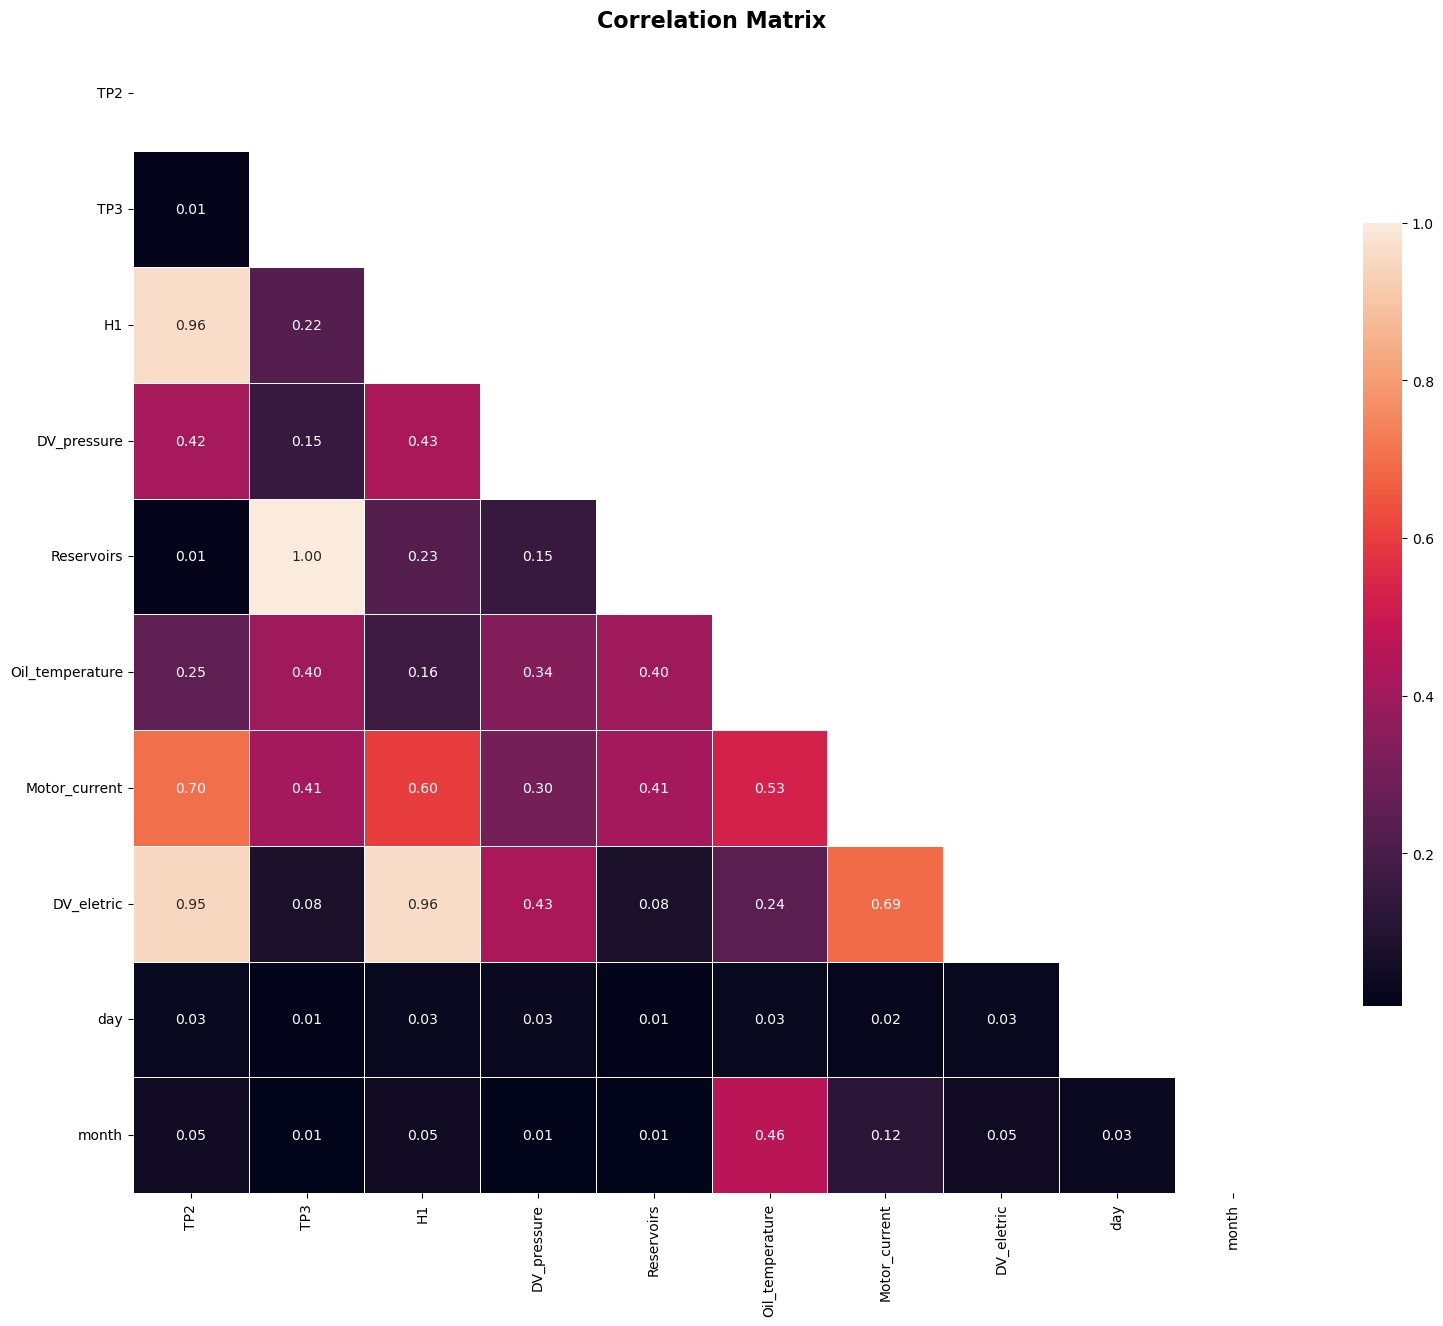

In [97]:
corr = np.abs(X.corr())

# Set up mask for triangle representation
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(16, 16))

# Generate a custom diverging colormap
cmap = sns.diverging_palette(220, 10, as_cmap=True)

# Draw the heatmap
sns.heatmap(corr, mask=mask, vmax=1, square=True, 
            linewidths=.5, cbar_kws={"shrink": .5},
            annot=True, fmt='.2f',   # fmt='.2f' to round to 2 decimals
            cmap='rocket', ax=ax)

plt.title('Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [98]:
# Split the data in a way that the test data contains 1 of the failures and the train 3 of the failures
split_index = int(len(df) * 0.7)
X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

In [99]:
# SMOTE with sampling_strategy = 0.05 
smote = SMOTE(sampling_strategy=0.05, random_state=42) 
X_train, y_train = smote.fit_resample(X_train, y_train)

In [100]:
# Fit the model
rf = RandomForestClassifier(
    max_depth=10,         
    min_samples_leaf=10,   
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


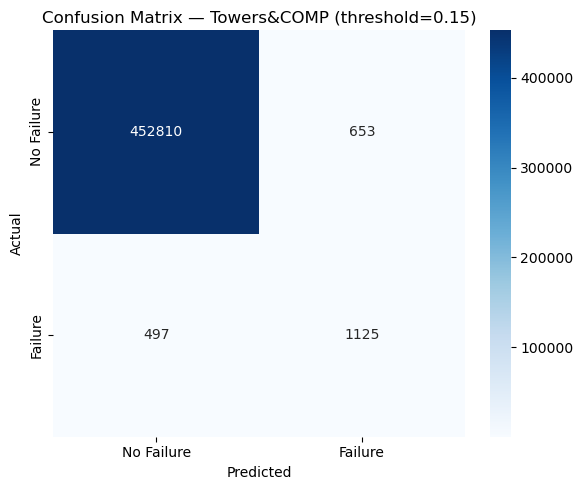

In [ ]:
results = evaluate_model(
    rf,
    X_train, X_test,
    y_train, y_test,
    'Droping_columns',
    'chronological split + SMOTE sampling_strategy=0.0.5 + threshold=0.15',
    threshold=0.15
)

In [ ]:
results

### Conclution
All the scores went up

# Cross Validation

In [ ]:
# Define parameter distribution for sampling
param_dist = {
    'n_estimators': [100, 200, 300, 500],   # number of trees
    'max_depth': [None, 10, 20, 30],        # tree depth
    'min_samples_split': [2, 5, 10],        # min samples to split
    'min_samples_leaf': [1, 2, 4],          # min samples per leaf
    'max_features': ['sqrt', 'log2', None]  # number of features per split
}

# Randomized search
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,                 # number of random combinations to try
    cv=3,                      # 3-fold cross-validation (faster than 5)
    scoring='neg_mean_squared_error',
    n_jobs=-1,                 # use all CPU cores
    verbose=2,
    random_state=42

# Fit randomized search
random_search.fit(X_train, y_train)

# Best parameters
print("Best parameters:", random_search.best_params_)

# Best model
best_rf = random_search.best_estimator_

# Evaluate on test set
y_prob = rf_res70.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.15).astype(int)

print(classification_report(y_test, y_pred, zero_division=0))



NameError: name 'RandomForestRegressor' is not defined